### Core Idea of RNN

**The key to RNN is:**

> **Current Output = Current Input + Past Memory**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [46]:
def forward_sequence(xs, Wx, Wh, bh, Wy, by):
    hs, ys, cache = {}, {}, {}
    h_prev = np.zeros((Wh.shape[0], 1))
    hs[-1] = h_prev

    for t in range(len(xs)):
        x_t = np.array([[xs[t]]], dtype=float)

        a_t = Wx @ x_t + Wh @ h_prev + bh     # 公式1
        h_t = np.tanh(a_t)                    # 公式2
        y_t = Wy @ h_t + by                   # 公式3

        hs[t] = h_t
        ys[t] = y_t
        cache[t] = (x_t, h_prev, a_t, h_t)

        h_prev = h_t

    return hs, ys, cache

In [47]:
def compute_loss(ys, targets):
    loss = 0.0
    T = len(targets)
    for t in range(T):
        target_t = np.array([[targets[t]]], dtype=float)
        loss += 0.5 * np.sum((ys[t] - target_t) ** 2)   # 公式4
    return loss / T                                     # 公式5

In [48]:
def backward_sequence(xs, targets, hs, ys, cache, Wx, Wh, bh, Wy, by):
    dWx = np.zeros_like(Wx)
    dWh = np.zeros_like(Wh)
    dbh = np.zeros_like(bh)
    dWy = np.zeros_like(Wy)
    dby = np.zeros_like(by)

    dh_next = np.zeros((Wh.shape[0], 1))
    T = len(xs)

    for t in reversed(range(T)):
        target_t = np.array([[targets[t]]], dtype=float)
        x_t, h_prev, a_t, h_t = cache[t]
        y_t = ys[t]

        dy = y_t - target_t              # 公式6
        dWy += dy @ h_t.T                # 公式7
        dby += dy                        # 公式8

        dh = Wy.T @ dy + dh_next         # 公式9
        da = dh * (1 - h_t ** 2)         # 公式10

        dWx += da @ x_t.T                # 公式11
        dWh += da @ h_prev.T             # 公式12
        dbh += da                        # 公式13

        dh_next = Wh.T @ da              # 公式14

    dWx /= T
    dWh /= T
    dbh /= T
    dWy /= T
    dby /= T

    return dWx, dWh, dbh, dWy, dby

RNN 常见问题是梯度爆炸。

简单做法：把梯度限制在一定范围内。

In [54]:
def clip_gradients(grads, min_value=-5, max_value=5):
    for grad in grads:
        np.clip(grad, min_value, max_value, out=grad)

In [49]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [52]:
input_size = 1
hidden_size = 8
output_size = 1

# 参数初始化
Wx = np.random.randn(hidden_size, input_size) * 0.1
Wh = np.random.randn(hidden_size, hidden_size) * 0.1
bh = np.zeros((hidden_size, 1))

Wy = np.random.randn(output_size, hidden_size) * 0.1
by = np.zeros((output_size, 1))

In [53]:
xs = [1, 2, 3, 4]
targets = [2, 3, 4, 5]

hs, ys, cache = forward_sequence(xs, Wx, Wh, bh, Wy, by)
loss = compute_loss(ys, targets)

dWx, dWh, dbh, dWy, dby = backward_sequence(
    xs, targets, hs, ys, cache, Wx, Wh, bh, Wy, by
)

print("loss =", loss)
print("dWx shape =", dWx.shape)
print("dWh shape =", dWh.shape)
print("dWy shape =", dWy.shape)

loss = 6.9325235231103965
dWx shape = (8, 1)
dWh shape = (8, 8)
dWy shape = (1, 8)


In [55]:
# 一个训练样本：输入序列 -> 输出序列
X_train = [
    [1, 2, 3, 4],
    [2, 3, 4, 5],
    [3, 4, 5, 6],
    [4, 5, 6, 7]
]

Y_train = [
    [2, 3, 4, 5],
    [3, 4, 5, 6],
    [4, 5, 6, 7],
    [5, 6, 7, 8]
]

In [56]:
def train_rnn(X_train, Y_train, Wx, Wh, bh, Wy, by, epochs=500, lr=0.01):
    loss_history = []
    
    for epoch in range(epochs):
        total_loss = 0.0
        
        # 累加所有样本的梯度
        sum_dWx = np.zeros_like(Wx)
        sum_dWh = np.zeros_like(Wh)
        sum_dbh = np.zeros_like(bh)
        sum_dWy = np.zeros_like(Wy)
        sum_dby = np.zeros_like(by)
        
        for xs, targets in zip(X_train, Y_train):
            hs, ys, cache = forward_sequence(xs, Wx, Wh, bh, Wy, by)
            loss = compute_loss(ys, targets)
            total_loss += loss
            
            dWx, dWh, dbh_, dWy, dby_ = backward_sequence(
                xs, targets, hs, ys, cache, Wx, Wh, bh, Wy, by
            )
            
            sum_dWx += dWx
            sum_dWh += dWh
            sum_dbh += dbh_
            sum_dWy += dWy
            sum_dby += dby_
        
        # 对 batch 平均
        n = len(X_train)
        sum_dWx /= n
        sum_dWh /= n
        sum_dbh /= n
        sum_dWy /= n
        sum_dby /= n
        
        # 梯度裁剪
        clip_gradients([sum_dWx, sum_dWh, sum_dbh, sum_dWy, sum_dby])
        
        # 参数更新
        Wx -= lr * sum_dWx
        Wh -= lr * sum_dWh
        bh -= lr * sum_dbh
        Wy -= lr * sum_dWy
        by -= lr * sum_dby
        
        avg_loss = total_loss / n
        loss_history.append(avg_loss)
        
        if epoch % 50 == 0:
            print(f"Epoch {epoch:4d}, Loss = {avg_loss:.6f}")
    
    return Wx, Wh, bh, Wy, by, loss_history

In [57]:
# 重新初始化参数
np.random.seed(42)

Wx = np.random.randn(hidden_size, input_size) * 0.1
Wh = np.random.randn(hidden_size, hidden_size) * 0.1
bh = np.zeros((hidden_size, 1))

Wy = np.random.randn(output_size, hidden_size) * 0.1
by = np.zeros((output_size, 1))

Wx, Wh, bh, Wy, by, loss_history = train_rnn(
    X_train, Y_train, Wx, Wh, bh, Wy, by,
    epochs=1000,
    lr=0.01
)

Epoch    0, Loss = 14.448361
Epoch   50, Loss = 0.487901
Epoch  100, Loss = 0.267755
Epoch  150, Loss = 0.157483
Epoch  200, Loss = 0.102388
Epoch  250, Loss = 0.072799
Epoch  300, Loss = 0.056063
Epoch  350, Loss = 0.045858
Epoch  400, Loss = 0.039038
Epoch  450, Loss = 0.034094
Epoch  500, Loss = 0.030293
Epoch  550, Loss = 0.027255
Epoch  600, Loss = 0.024761
Epoch  650, Loss = 0.022674
Epoch  700, Loss = 0.020901
Epoch  750, Loss = 0.019377
Epoch  800, Loss = 0.018054
Epoch  850, Loss = 0.016895
Epoch  900, Loss = 0.015873
Epoch  950, Loss = 0.014967


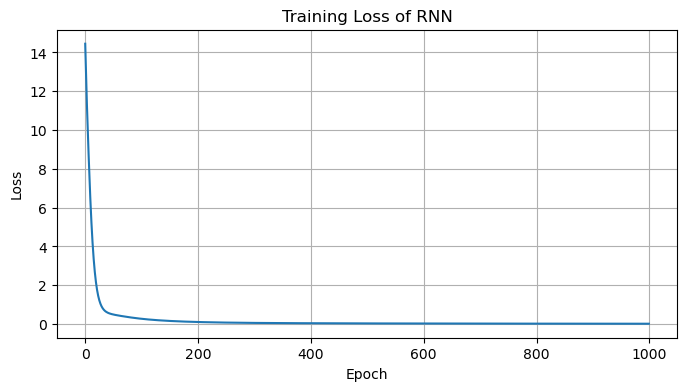

In [58]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss of RNN")
plt.grid(True)
plt.show()

In [59]:
def predict_sequence(xs, Wx, Wh, bh, Wy, by):
    hs, ys, cache = forward_sequence(xs, Wx, Wh, bh, Wy, by)
    preds = [ys[t].ravel()[0] for t in range(len(xs))]
    return preds

In [60]:
test_seq = [5, 6, 7, 8]
preds = predict_sequence(test_seq, Wx, Wh, bh, Wy, by)

print("输入序列:", test_seq)
print("预测输出:", [round(p, 3) for p in preds])
print("理想输出:", [6, 7, 8, 9])

输入序列: [5, 6, 7, 8]
预测输出: [5.838, 6.776, 7.484, 7.923]
理想输出: [6, 7, 8, 9]


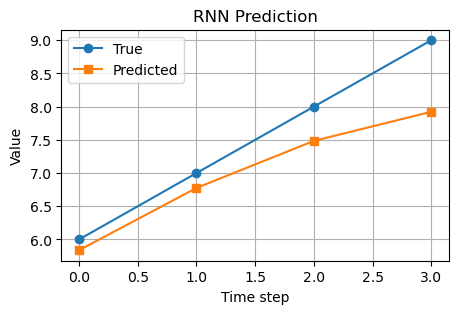

In [64]:
true_values = [6, 7, 8, 9]

plt.figure(figsize=(5, 3))
plt.plot(true_values, marker='o', label='True')
plt.plot(preds, marker='s', label='Predicted')
plt.xlabel("Time step")
plt.ylabel("Value")
plt.title("RNN Prediction")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
true_values = [6, 7, 8, 9]

plt.figure(figsize=(5, 3))
plt.plot(true_values, marker='o', label='True')
plt.plot(preds, marker='s', label='Predicted')
plt.xlabel("Time step")
plt.ylabel("Value")
plt.title("RNN Prediction")
plt.legend()
plt.grid(True)
plt.show()